# Understanding the KDE Plot (Kernel Density Estimate)

A KDE plot is a **smooth, continuous version of the histogram**. Instead of counting observations per bin, it places a small kernel function (usually Gaussian) at each data point and sums them into a smooth curve. The area under the curve always equals 1. Unlike a histogram, KDE has no bin width to choose — instead it has **bandwidth (h)**, which controls smoothness. KDE is used both as a standalone univariate plot and as the density contour in bivariate analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

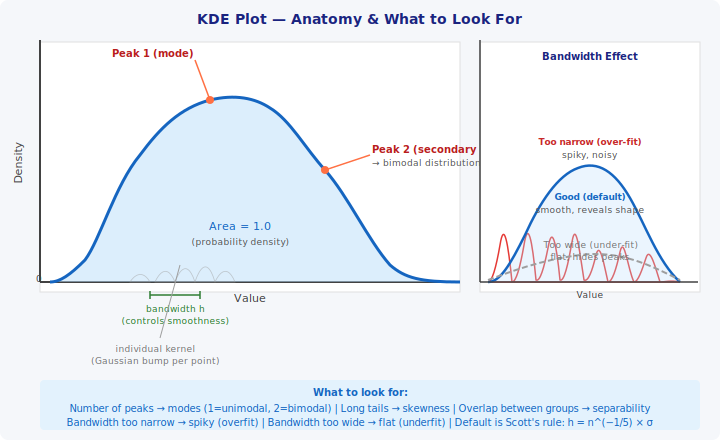

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">KDE Plot — Anatomy &amp; What to Look For</text>

  <!-- ── MAIN ANATOMY PANEL ── -->
  <rect x="40" y="42" width="420" height="250" fill="white" stroke="#E0E0E0"/>

  <!-- Zero baseline -->
  <line x1="40" y1="282" x2="460" y2="282" stroke="#424242" stroke-width="2"/>
  <line x1="40" y1="282" x2="40"  y2="40"  stroke="#424242" stroke-width="2"/>

  <!-- Shaded area under curve -->
  <path d="M 50,282 C 60,282 70,275 85,260 C 100,240 115,185 140,155
           C 160,128 180,108 210,100 C 235,94 255,98 270,108
           C 290,120 305,148 325,170 C 348,196 368,240 390,265
           C 405,278 420,282 460,282 Z"
        fill="#BBDEFB" opacity="0.5"/>

  <!-- KDE curve (bimodal: two peaks) -->
  <path d="M 50,282 C 60,282 70,275 85,260 C 100,240 115,185 140,155
           C 160,128 180,108 210,100 C 235,94 255,98 270,108
           C 290,120 305,148 325,170 C 348,196 368,240 390,265
           C 405,278 420,282 460,282"
        fill="none" stroke="#1565C0" stroke-width="3" stroke-linejoin="round"/>

  <!-- Individual kernel Gaussians (small bumps) under curve -->
  <path d="M 130,282 C 130,282 140,265 150,282 Z"
        fill="none" stroke="#9E9E9E" stroke-width="0.8" opacity="0.5"/>
  <path d="M 155,282 C 155,282 165,258 175,282 Z"
        fill="none" stroke="#9E9E9E" stroke-width="0.8" opacity="0.5"/>
  <path d="M 175,282 C 175,282 185,252 195,282 Z"
        fill="none" stroke="#9E9E9E" stroke-width="0.8" opacity="0.5"/>
  <path d="M 195,282 C 195,282 205,248 215,282 Z"
        fill="none" stroke="#9E9E9E" stroke-width="0.8" opacity="0.5"/>
  <path d="M 215,282 C 215,282 225,258 235,282 Z"
        fill="none" stroke="#9E9E9E" stroke-width="0.8" opacity="0.5"/>

  <!-- Peak 1 annotation -->
  <line x1="210" y1="100" x2="195" y2="60" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="210" cy="100" r="4" fill="#FF7043"/>
  <text x="193" y="57" text-anchor="end" font-size="10" font-weight="bold" fill="#B71C1C">Peak 1 (mode)</text>

  <!-- Peak 2 annotation -->
  <line x1="325" y1="170" x2="370" y2="155" stroke="#FF7043" stroke-width="1.5"/>
  <circle cx="325" cy="170" r="4" fill="#FF7043"/>
  <text x="372" y="153" font-size="10" font-weight="bold" fill="#B71C1C">Peak 2 (secondary mode)</text>
  <text x="372" y="166" font-size="9" fill="#555">→ bimodal distribution</text>

  <!-- Area annotation -->
  <text x="240" y="230" text-anchor="middle" font-size="11" fill="#1565C0">Area = 1.0</text>
  <text x="240" y="245" text-anchor="middle" font-size="9" fill="#555">(probability density)</text>

  <!-- Bandwidth bracket on x-axis -->
  <line x1="150" y1="295" x2="200" y2="295" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="150" y1="291" x2="150" y2="299" stroke="#2E7D32" stroke-width="1.5"/>
  <line x1="200" y1="291" x2="200" y2="299" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="175" y="312" text-anchor="middle" font-size="9" fill="#2E7D32">bandwidth h</text>
  <text x="175" y="324" text-anchor="middle" font-size="9" fill="#2E7D32">(controls smoothness)</text>

  <!-- Kernel label -->
  <line x1="180" y1="265" x2="160" y2="338" stroke="#9E9E9E" stroke-width="1"/>
  <text x="155" y="352" text-anchor="middle" font-size="9" fill="#757575">individual kernel</text>
  <text x="155" y="364" text-anchor="middle" font-size="9" fill="#757575">(Gaussian bump per point)</text>

  <!-- Axes labels -->
  <text x="250" y="302" text-anchor="middle" font-size="11" fill="#424242">Value</text>
  <text x="22" y="162" text-anchor="middle" font-size="11" fill="#424242"
        transform="rotate(-90 22 162)">Density</text>
  <text x="42" y="282" text-anchor="end" font-size="9" fill="#424242">0</text>

  <!-- ── RIGHT PANEL: bandwidth effect ── -->
  <rect x="480" y="42" width="220" height="250" fill="white" stroke="#E0E0E0"/>
  <text x="590" y="60" text-anchor="middle" font-size="10" font-weight="bold" fill="#1A237E">Bandwidth Effect</text>

  <!-- Under-smoothed (too narrow BW) -->
  <path d="M 488,282 C 492,282 496,268 500,245 C 504,220 508,242 512,282
           C 516,282 520,268 524,245 C 528,220 532,238 536,280
           C 540,282 544,268 548,248 C 552,225 556,240 560,280
           C 564,282 568,265 572,242 C 576,218 580,255 584,280
           C 588,282 592,272 596,255 C 600,240 604,265 608,282
           C 612,282 616,270 620,252 C 624,234 628,270 634,282
           C 638,282 642,270 646,258 C 650,245 656,270 660,282
           C 665,282 670,280 680,282 Z"
        fill="none" stroke="#E53935" stroke-width="1.5"/>
  <text x="590" y="145" text-anchor="middle" font-size="9" font-weight="bold" fill="#C62828">Too narrow (over-fit)</text>
  <text x="590" y="158" text-anchor="middle" font-size="9" fill="#555">spiky, noisy</text>

  <!-- Just-right -->
  <path d="M 488,282 C 500,282 510,265 525,235 C 540,202 558,175 578,168
           C 598,160 615,172 630,198 C 645,224 658,262 680,282 Z"
        fill="#BBDEFB" opacity="0.3"/>
  <path d="M 488,282 C 500,282 510,265 525,235 C 540,202 558,175 578,168
           C 598,160 615,172 630,198 C 645,224 658,262 680,282"
        fill="none" stroke="#1565C0" stroke-width="2.5"/>
  <text x="590" y="200" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">Good (default)</text>
  <text x="590" y="213" text-anchor="middle" font-size="9" fill="#555">smooth, reveals shape</text>

  <!-- Over-smoothed (too wide BW) -->
  <path d="M 488,280 C 510,272 540,260 580,255 C 620,250 650,265 680,280"
        fill="none" stroke="#9E9E9E" stroke-width="2" stroke-dasharray="6,3"/>
  <text x="590" y="248" text-anchor="middle" font-size="9" fill="#757575">Too wide (under-fit)</text>
  <text x="590" y="260" text-anchor="middle" font-size="9" fill="#757575">flat, hides peaks</text>

  <!-- axis -->
  <line x1="480" y1="282" x2="698" y2="282" stroke="#424242" stroke-width="1.5"/>
  <line x1="480" y1="282" x2="480" y2="40"  stroke="#424242" stroke-width="1.5"/>
  <text x="590" y="298" text-anchor="middle" font-size="9" fill="#424242">Value</text>

  <!-- TAKEAWAY -->
  <rect x="40" y="380" width="660" height="50" fill="#E3F2FD" rx="4"/>
  <text x="360" y="396" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="360" y="412" text-anchor="middle" font-size="10" fill="#1565C0">Number of peaks → modes (1=unimodal, 2=bimodal)   |   Long tails → skewness   |   Overlap between groups → separability</text>
  <text x="360" y="426" text-anchor="middle" font-size="10" fill="#1565C0">Bandwidth too narrow → spiky (overfit)   |   Bandwidth too wide → flat (underfit)   |   Default is Scott's rule: h = n^(−1/5) × σ</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a KDE Plot

| Feature | What it tells you |
|---|---|
| **One peak** | Unimodal — single most common value range |
| **Two peaks** | Bimodal — two subpopulations (investigate with grouping) |
| **Long right tail** | Right-skewed — few large values |
| **Overlapping KDEs (multi-group)** | Distributions overlap → harder to separate for classification |
| **Non-overlapping KDEs** | Classes well-separated → feature is highly discriminative |
| **Spiky curve** | Bandwidth too small — reduce `bw_adjust` or use default |
| **Flat/wide curve** | Bandwidth too large — missing peaks |

**Bandwidth rule of thumb:** seaborn uses Scott's rule by default (h = n^(−1/5) × σ). Use `bw_adjust` to multiply the default bandwidth: `bw_adjust=0.5` for sharper, `bw_adjust=2` for smoother.

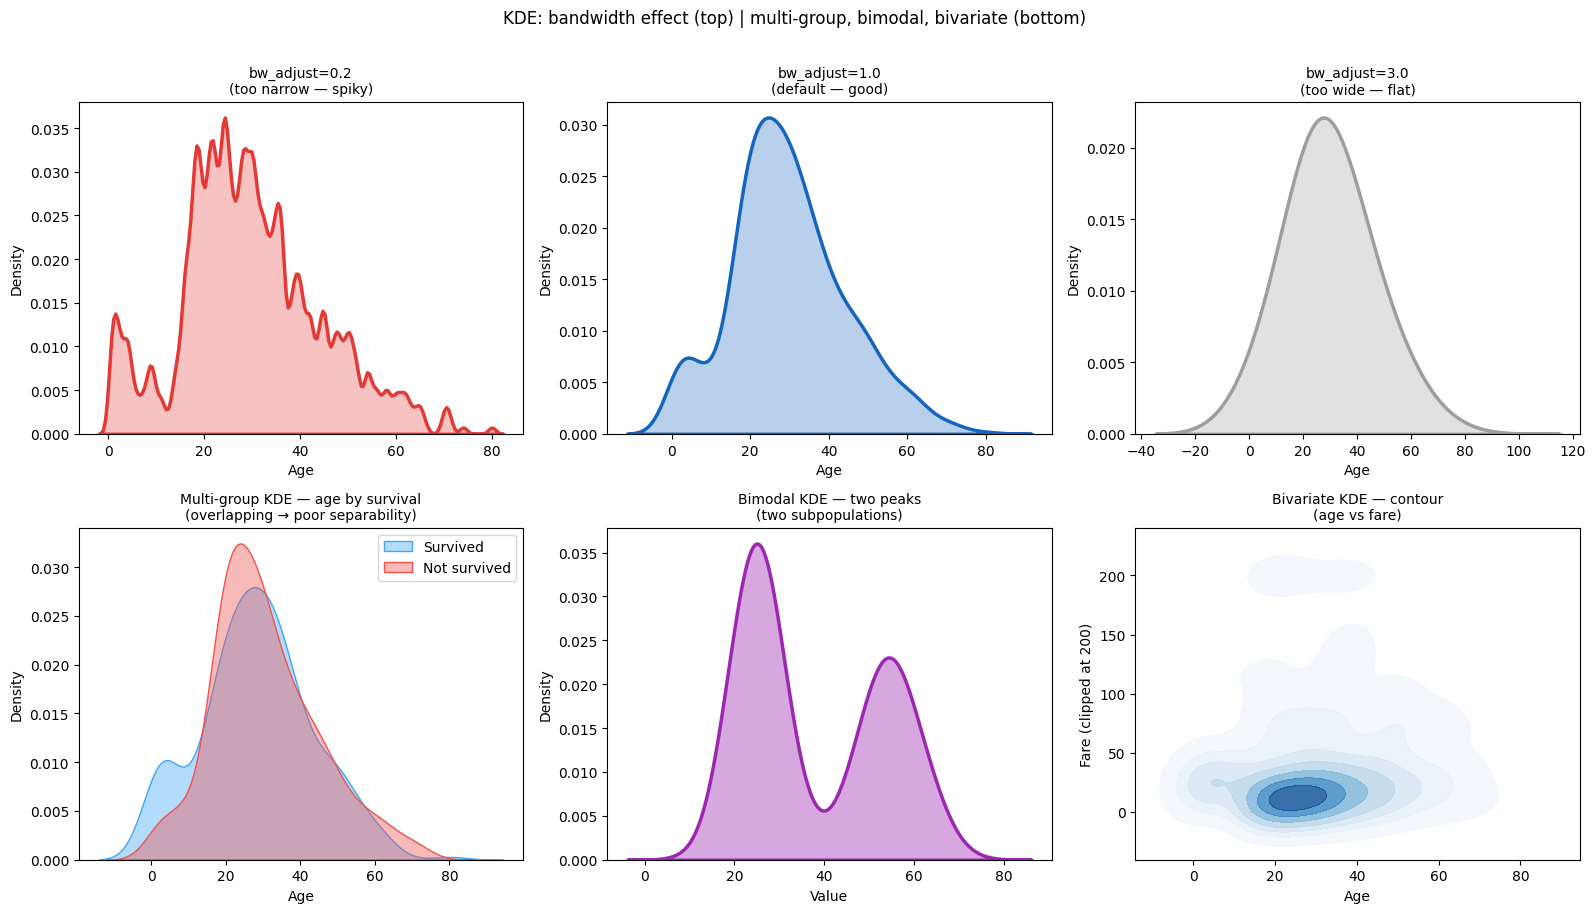

In [3]:
df = sns.load_dataset('titanic').dropna(subset=['age'])
np.random.seed(42)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── Row 1: Bandwidth effect ──
age = df['age'].values
for ax, bw, label, color in zip(
    axes[0],
    [0.2, 1.0, 3.0],
    ['bw_adjust=0.2\n(too narrow — spiky)', 'bw_adjust=1.0\n(default — good)', 'bw_adjust=3.0\n(too wide — flat)'],
    ['#E53935', '#1565C0', '#9E9E9E']
):
    sns.kdeplot(age, bw_adjust=bw, ax=ax, color=color, fill=True, alpha=0.3, linewidth=2.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Age')
    ax.set_ylabel('Density')

# ── Row 2: Multi-group KDE ──

# Overlapping groups (poor separability)
survived    = df[df['survived'] == 1]['age']
not_survived = df[df['survived'] == 0]['age']
sns.kdeplot(survived,     ax=axes[1, 0], label='Survived',     fill=True, alpha=0.4, color='#42A5F5')
sns.kdeplot(not_survived, ax=axes[1, 0], label='Not survived', fill=True, alpha=0.4, color='#EF5350')
axes[1, 0].set_title('Multi-group KDE — age by survival\n(overlapping → poor separability)', fontsize=10)
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Bimodal KDE
bimodal = np.concatenate([np.random.normal(25, 5, 400), np.random.normal(55, 6, 300)])
sns.kdeplot(bimodal, ax=axes[1, 1], fill=True, alpha=0.4, color='#9C27B0', linewidth=2.5)
axes[1, 1].set_title('Bimodal KDE — two peaks\n(two subpopulations)', fontsize=10)
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Density')

# Bivariate KDE (contour)
axes[1, 2].set_title('Bivariate KDE — contour\n(age vs fare)', fontsize=10)
fare_clip = df['fare'].clip(upper=200)
sns.kdeplot(data=df, x='age', y=fare_clip, ax=axes[1, 2],
            fill=True, levels=8, cmap='Blues', alpha=0.8)
axes[1, 2].set_xlabel('Age')
axes[1, 2].set_ylabel('Fare (clipped at 200)')

plt.suptitle('KDE: bandwidth effect (top) | multi-group, bimodal, bivariate (bottom)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Shape of a continuous distribution — smoother alternative to histogram |
| **Area** | Always = 1.0 (probability density, not count) |
| **Bandwidth** | Controls smoothness — default (Scott's rule) is usually fine |
| **`bw_adjust`** | Multiplier on default bandwidth: <1 = sharper, >1 = smoother |
| **Multi-group** | Overlay multiple KDEs to compare distributions — look for separation |
| **Bivariate KDE** | 2D contour showing joint density of two numerical variables |
| **vs Histogram** | KDE is continuous and smooth; histogram is discrete bins — use both together |
| **Pairs with** | Histogram (same info, different view) + Q-Q plot (normality check) |